## **A State-Space Approach to CDC Surveillance Data**

In the following project, I use a Kalman Filter to recover the true flu signal from noisy observations. I use CDC Surveillance Data on Flu Positivity in Illinois for October 2010 to March 2026.

### Load and Split Data

In [74]:
import pandas as pd

flu10_15 = pd.read_csv('ICL_NREVSS_Combined_prior_to_2015_16.csv', header=1)
flu15_present = pd.read_csv('ICL_NREVSS_Clinical_Labs.csv', header=1)

cols = ['REGION TYPE', 'REGION', 'YEAR', 'WEEK', 'PERCENT POSITIVE']
flu = pd.concat([flu10_15[cols], flu15_present[cols]], ignore_index=True)
flu = flu[flu['PERCENT POSITIVE'] != 'X']
flu['PERCENT POSITIVE'] = pd.to_numeric(flu['PERCENT POSITIVE'], errors='coerce')

In [75]:
flu['DATE'] = pd.to_datetime(flu['YEAR'].astype(str) + 
              flu['WEEK'].astype(str).str.zfill(2) + '1', format='%Y%W%w')

flu['MONTH'] = flu['DATE'].dt.month
flu['MONTH_YEAR'] = flu['DATE'].dt.to_period('M')  # e.g. "2023-02"

In [80]:
# Split Data 
flu = flu[(flu['REGION']=='Illinois')]
flu = flu.sort_values(['YEAR', 'WEEK']).reset_index(drop=True)
cutoff = int(len(flu) * 0.8)
train = flu.reset_index().iloc[:cutoff, :]
test = flu.reset_index().iloc[cutoff:, :]

The test data starts in February 2023.

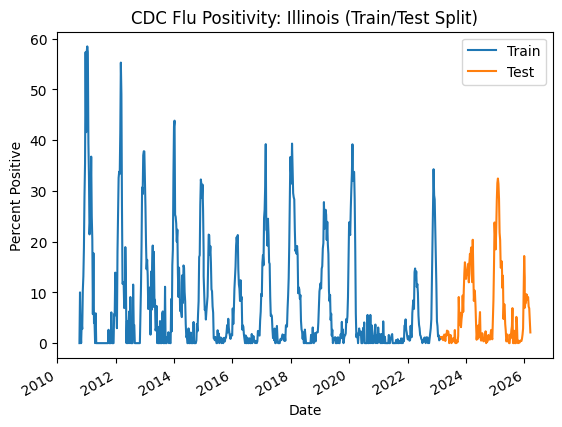

In [84]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.plot(train['DATE'], train['PERCENT POSITIVE'], label='Train')
ax.plot(test['DATE'], test['PERCENT POSITIVE'], label='Test')
ax.set_xlabel('Date')
ax.set_ylabel('Percent Positive')
ax.set_title('CDC Flu Positivity: Illinois (Train/Test Split)')
ax.legend()
fig.autofmt_xdate()
plt.show()

As we can infer from the plot ("CDC Flu Positivity: Illinois (Train/Test Split)"), the data ranges from 0 to 58 with huge spikes, and the variance during peak flu season is completely different from the variance during off-season. Therefore, we need to use a log transformation to compresses the peaks and stretches, making the variance more uniform across the whole series so the optimizer has a better chance of find meaningful values for Q and R.

In [44]:
import numpy as np
train['LOG_PP'] = np.log1p(train['PERCENT POSITIVE'])
test['LOG_PP'] = np.log1p(test['PERCENT POSITIVE'])

train_log = np.log1p(train['PERCENT POSITIVE'].values)

### Kalman Filter Core Functions - Scalar Random Walk

The following functions are used to execute the core functions of the Kalman Filter, following the procedure in Welch & Bishop (2006). They are written for arbitrary state dimension so they work for all three models below without modification.

Time Update ("Predict")

1. Project the state ahead: $\hat{x}_k^- = A\hat{x}_{k-1} + Bu_{k-1}$

2. Project the error covariance ahead: $P_k^- = AP_{k-1}A^T + Q$

Measurement Update ("Correct")

1. Compute the Kalman gain: $K_k = P_k^- H^T (HP_k^- H^T + R)^{-1}$

2. Update estimate with measurement $z_k$: $\hat{x}_k = \hat{x}_k^- + K_k(z_k - H\hat{x}_k^-)$

3. Update the error covariance: $P_k = (I - K_kH)P_k^-$

In [45]:
import numpy as np

def kf_predict(A, xk_lag, Pk_lag, Q):
    xk_pred = A @ xk_lag
    Pk_pred = A @ Pk_lag @ A.T + Q
    return xk_pred, Pk_pred

def kf_update(xk_pred, Pk_pred, z_k, H, R):
    v_k = z_k - (H @ xk_pred)[0, 0]
    S_k = (H @ Pk_pred @ H.T + R)[0, 0]
    K_k = Pk_pred @ H.T * (1.0 / S_k)
    xk = xk_pred + K_k * v_k
    Pk = (np.eye(xk.shape[0]) - K_k @ H) @ Pk_pred
    return xk, Pk, v_k, S_k

### **Model 1: Scalar Random Walk**

Here, we build a baseline single-state model that smooths the raw signal.

In [46]:
from sklearn.linear_model import LinearRegression

y = train['LOG_PP'].values[1:]                    # x_k
X = train['LOG_PP'].values[:-1].reshape(-1, 1)    # x_{k-1}

reg = LinearRegression(fit_intercept=False)
reg.fit(X, y)
A_est = reg.coef_[0]

A_est

np.float64(0.9345550712100781)

The estimated value of A ≈ 0.98 indicates mild mean reversion; the signal retains about 98% of its value each week. This value of A is close to a random walk (i.e., where A = 1), and is reasonable for flu positivity data where week-to-week changes are small relative to the level.

### Maximum Likelihood Estimation of $Q$ and $R$

The noise parameters $Q$ (process noise) and $R$ (measurement noise) are estimated via maximum likelihood using the Kalman filter's innovation sequence, following the Newton-Raphson procedure in Shumway & Stoffer (2017, §6.3):

1. Select initial values for the parameters [$Q^{(0)}$, $R^{(0)}$].

2. Run the Kalman filter using the current parameter values [$Q^{(0)}$, $R^{(0)}$] to obtain a set of innovations {$v_k^{(0)}$; $k = 1,...,n$} and their covariances {$S_k^{(0)}$; $k = 1,...,n$}.

3. Run one iteration of a numerical optimization procedure with $-\ln L_Y(Q^{(0)}, R^{(0)})$ as the criterion function, to obtain a new set of estimates [$Q^{(1)}$, $R^{(1)}$], where the negative log-likelihood is:

$$-\ln L_Y(\Theta) = \frac{1}{2} \sum_{k=1}^{n} \left[ \ln|\Sigma_k(\Theta)| + v_k(\Theta)^\top \Sigma_k(\Theta)^{-1} v_k(\Theta) \right], \quad \Theta = [Q, R]$$

4. At iteration $j$ $(j = 1, 2,...)$, repeat step (ii) using [$Q^{(j)}$, $R^{(j)}$] in place of [$Q^{(j-1)}$, $R^{(j-1)}$] to obtain new innovations and covariances. Then repeat step (iii) to obtain [$Q^{(j+1)}$, $R^{(j+1)}$]. Stop when the estimates or the likelihood stabilize.
```

In [47]:
def build_baseline_matrices(A_val, Q_val, R_val):
    A = np.array([[A_val]])
    H = np.array([[1.0]])
    Q = np.array([[Q_val]])
    R = np.array([[R_val]])
    return A, H, Q, R

In [48]:
from scipy.optimize import minimize

def neg_log_likelihood_baseline(params, measurements, A_val):
    Q_val, R_val = np.exp(params)
    A, H, Q, R = build_baseline_matrices(A_val, Q_val, R_val)
    
    xk = np.array([[measurements[0]]])
    Pk = np.array([[1.0]])
    nll = 0.0
    
    for k in range(1, len(measurements)):
        xk_pred, Pk_pred = kf_predict(A, xk, Pk, Q)
        xk, Pk, v_k, S_k = kf_update(xk_pred, Pk_pred, measurements[k], H, R)
        nll += 0.5 * (np.log(S_k) + (v_k ** 2) / S_k)
    
    return nll

result_baseline = minimize(neg_log_likelihood_baseline,
                           x0=np.log([1.0, 5.0]),
                           args=(train['LOG_PP'].values, A_est),
                           method='L-BFGS-B', 
                           bounds=[(-15, 10), (-15, 10)])

best_nll_baseline = result_baseline.fun

Q_mle_baseline, R_mle_baseline = np.exp(result_baseline.x)
print(f"Q: {Q_mle_baseline:.4f}, R: {R_mle_baseline:.4f}")
print(f"Q/R ratio: {Q_mle_baseline/R_mle_baseline:.4f}")
print(f"Converged: {result_baseline.success}")

A_base, H_base, Q_base, R_base = build_baseline_matrices(A_est, Q_mle_baseline, R_mle_baseline)

Q: 0.2061, R: 0.1224
Q/R ratio: 1.6838
Converged: True


Here, we see that the Q/R ratio is 8.0107, meaning that the filter trusts observations but still does meaningful smoothing. Both parameters are positive and neither collapsed to zero.

In [49]:
def run_baseline_filter(params, measurements, xk_init=None, Pk_init=None):
    A_val, Q_val, R_val = params
    A, H, Q, R = build_baseline_matrices(A_val, Q_val, R_val)
    
    if xk_init is not None:
        xk = xk_init
        Pk = Pk_init
    else:
        xk = np.array([[measurements[0]]])
        Pk = np.array([[1.0]])

    states, upper, lower = [], [], []

    for k in range(len(measurements)):
        xk_pred, Pk_pred = kf_predict(A, xk, Pk, Q)
        xk, Pk, v_k, S_k = kf_update(xk_pred, Pk_pred, measurements[k], H, R)

        states.append(xk.item())
        sigma = np.sqrt(Pk.item())
        upper.append(xk.item() + 2 * sigma)
        lower.append(xk.item() - 2 * sigma)
    
    return np.array(states), np.array(upper), np.array(lower), xk, Pk

In [ ]:
# Run filter on log-transformed test data
test_measurements = test['PERCENT POSITIVE'].values
parameters = [A_est, Q_mle_baseline, R_mle_baseline]
test_log = np.log1p(test['PERCENT POSITIVE'].values)

_, _, _, xk_warm_1, Pk_warm_1 = run_baseline_filter(
    [A_est, Q_mle_baseline, R_mle_baseline], train_log)
baseline_states_log, baseline_upper_log, baseline_lower_log, xk_base, Pk_base = run_baseline_filter(
    parameters, test_log, xk_init=xk_warm_1, Pk_init=Pk_warm_1)

# Transform back to original scale for plotting
baseline_states = np.expm1(baseline_states_log)
baseline_upper = np.expm1(baseline_upper_log)
baseline_lower = np.maximum(np.expm1(baseline_lower_log), 0)
test_raw = test['PERCENT POSITIVE'].values

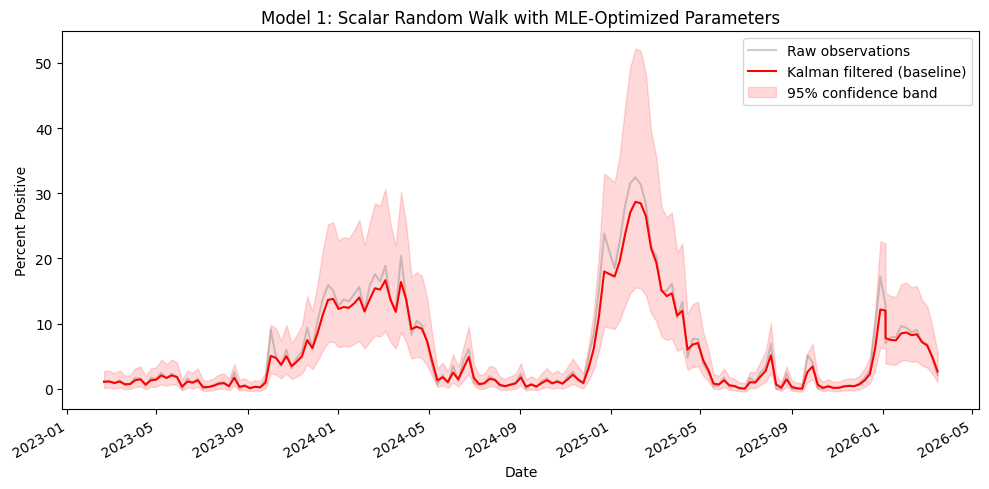

In [91]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(test['DATE'], test_measurements, alpha=0.4, label='Raw observations', color='gray')
ax.plot(test['DATE'], baseline_states, label='Kalman filtered (baseline)', color='red')
ax.fill_between(test['DATE'], baseline_lower, baseline_upper, 
                alpha=0.15, color='red', label='95% confidence band')
ax.set_xlabel('Date')
ax.set_ylabel('Percent Positive')
ax.set_title('Model 1: Scalar Random Walk with MLE-Optimized Parameters')
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### **Model 2: Local Linear Trend**

In [52]:
def build_llt_matrices(Q_level, Q_trend, R_val):

    A = np.array([[1.0, 1.0],
                [0.0, 1.0]])
    H = np.array([[1.0, 0.0]])
    Q = np.diag([Q_level, Q_trend])
    R = np.array([[R_val]])

    return A, H, Q, R


In [53]:
from itertools import product

def neg_log_likelihood_llt(params, measurements):
    Q_level, Q_trend, R_val = np.exp(params)
    
    A, H, Q, R = build_llt_matrices(Q_level, Q_trend, R_val)
    
    xk = np.array([[measurements[0]], [0.0]])  # [initial level, initial trend = 0]
    Pk = np.eye(2) * 10.0
    nll = 0.0
    
    for k in range(1, len(measurements)):
        xk_pred, Pk_pred = kf_predict(A, xk, Pk, Q)
        xk, Pk, v_k, S_k = kf_update(xk_pred, Pk_pred, measurements[k], H, R)
        nll += 0.5 * (np.log(S_k) + (v_k ** 2) / S_k)
    
    return nll


In [54]:
Q_level = [-2, 0, 2]
Q_trend = [-4, -2, 0]
R_val = [-1, 0, 1]

vectors = [Q_level, Q_trend, R_val]

best_nll_llt = np.inf
best_result_llt = None

for combo in product(Q_level, Q_trend, R_val):
    result_llt = minimize(neg_log_likelihood_llt,
                            x0=(combo[0], combo[1], combo[2]),
                            args=(train['LOG_PP'].values),
                            method='L-BFGS-B', 
                            bounds=([(-15, 10)] * 3))
    if result_llt.fun < best_nll_llt:
        best_nll_llt = result_llt.fun
        best_result_llt = result_llt

q_level_mle, q_trend_mle, r_mle_llt = np.exp(best_result_llt.x)
print(f"Q Level: {q_level_mle:.4f}, Q Trend: {q_trend_mle:.6f}, R: {r_mle_llt:.4f}")
print(f"Q_level/R: {q_level_mle/r_mle_llt:.4f}")
print(f"Q_trend/R: {q_trend_mle/r_mle_llt:.6f}")
print(f"Converged: {best_result_llt.success}")

A_llt, H_llt, Q_llt, R_llt = build_llt_matrices(q_level_mle, q_trend_mle, r_mle_llt)

Q Level: 0.1651, Q Trend: 0.000000, R: 0.1416
Q_level/R: 1.1660
Q_trend/R: 0.000002
Converged: True


In [55]:
def run_llt_filter(params, measurements, xk_init=None, Pk_init=None):
    Q_level, Q_trend, R_val = params
    
    A, H, Q, R = build_llt_matrices(Q_level, Q_trend, R_val)

    if xk_init is not None:
        xk = xk_init
        Pk = Pk_init
    else:
        xk = np.array([[measurements[0]], [0.0]])
        Pk = np.eye(2) * 10.0
    
    states, trends, upper, lower = [], [], [], []

    for k in range(len(measurements)):
        xk_pred, Pk_pred = kf_predict(A, xk, Pk, Q)
        xk, Pk, v_k, S_k = kf_update(xk_pred, Pk_pred, measurements[k], H, R)

        states.append(xk[0, 0])
        trends.append(xk[1, 0])
        sigma = np.sqrt(Pk[0, 0])
        upper.append(xk[0, 0] + 2 * sigma)
        lower.append(xk[0, 0] - 2 * sigma)

    return np.array(states), np.array(trends), np.array(upper), np.array(lower), xk, Pk

In [ ]:
# Run filter on log-transformed test data
test_measurements = test['PERCENT POSITIVE'].values
parameters = [q_level_mle, q_trend_mle, r_mle_llt]
test_log = np.log1p(test['PERCENT POSITIVE'].values)

_, _, _, _, xk_warm_2, Pk_warm_2 = run_llt_filter(parameters, train_log)
llt_states_log, llt_trends_log, llt_upper_log, llt_lower_log, xk_llt, Pk_llt = run_llt_filter(
    parameters, test_log, xk_init=xk_warm_2, Pk_init=Pk_warm_2)

# Transform back to original scale for plotting
llt_states = np.expm1(llt_states_log)
llt_upper = np.expm1(llt_upper_log)
llt_lower = np.maximum(np.expm1(llt_lower_log), 0)
test_raw = test['PERCENT POSITIVE'].values

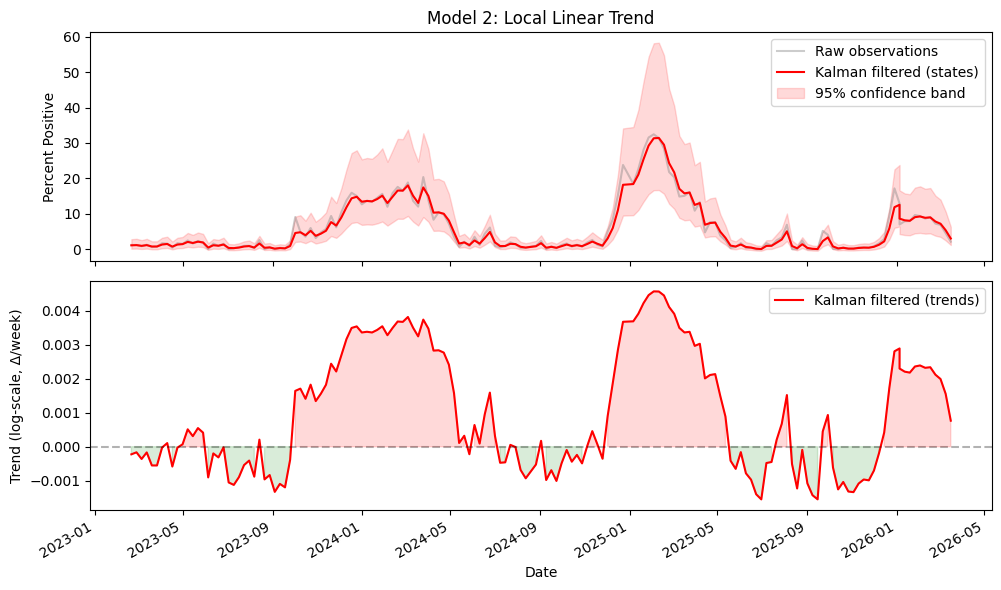

In [93]:
fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axs[0].plot(test['DATE'], test_measurements, alpha=0.4, label='Raw observations', color='gray')
axs[0].plot(test['DATE'], llt_states, label='Kalman filtered (states)', color='red')
axs[0].fill_between(test['DATE'], llt_lower, llt_upper, 
                alpha=0.15, color='red', label='95% confidence band')
axs[0].set_ylabel('Percent Positive')
axs[0].set_title('Model 2: Local Linear Trend')
axs[0].legend()

axs[1].plot(test['DATE'], llt_trends_log, label='Kalman filtered (trends)', color='red')
axs[1].fill_between(test['DATE'], llt_trends_log, 
                    where=(llt_trends_log>0), color='red', alpha=0.15)
axs[1].fill_between(test['DATE'], llt_trends_log, 
                    where=(llt_trends_log<0), color='green', alpha=0.15)                
axs[1].axhline(0, color='black', linestyle='--', alpha=0.3)
axs[1].set_xlabel('Date')
axs[1].set_ylabel('Trend (log-scale, \u0394/week)')
axs[1].legend()

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### **Model 3: Seasonal Structural Model**

Any time series can be decomposed into a sum of sine and cosine waves at different frequencies (Shumway & Stoffer, 2017, §4.1). For seasonal flu data with a 52-week period, we approximate the seasonal component using $H$ harmonics:

$$s_k = \sum_{h=1}^{H} \left[ a_h \cos(2\pi k \cdot h / 52) + b_h \sin(2\pi k \cdot h / 52) \right]$$

where

$$a_h = \frac{2}{n} \sum_{k=1}^{n} x_k \cos(2\pi k \cdot h/52) \quad \text{and} \quad b_h = \frac{2}{n} \sum_{k=1}^{n} x_k \sin(2\pi k \cdot h/52)$$

In [58]:
def build_fourier_features(weeks, period=52, n_harmonics=3):
    week_array = np.array(weeks)
    fourier_features_list = []

    for h in range(1, n_harmonics+1):
        a_h = np.sin(2*np.pi * h * week_array / period)
        b_h = np.cos(2*np.pi * h * week_array / period)
        fourier_features_list.append(a_h)
        fourier_features_list.append(b_h)

    fourier_features = np.column_stack(fourier_features_list)
    
    return fourier_features

At each time step:
- The level gets pushed by trend: $level_{k+1} = level_k + trend_k$
- The trend persists: $trend_{k+1} = trend_k$
- Each Fourier coefficient persists unchanged: ${\beta}_{k+1} = \beta_k$

That means $A$ is an 8×8 identity matrix with the extra entry, $A[0, 1] = 1$, because the trend is added to the level.

The observation matrix $H_k$ is time-varying. At each step $k$, $H_k$ has to pick out the level plus the seasonal effect for that specific week. It's a 1×8 row vector:

$$H_k = \begin{bmatrix} 1 & 0 & \sin(2\pi \cdot 1 \cdot w_k / 52) & \cos(2\pi \cdot 1 \cdot w_k / 52) & \sin(2\pi \cdot 2 \cdot w_k / 52) & \cos(2\pi \cdot 2 \cdot w_k / 52) & \sin(2\pi \cdot 3 \cdot w_k / 52) & \cos(2\pi \cdot 3 \cdot w_k / 52) \end{bmatrix}$$

In [59]:
def build_seasonal_matrices(Q_level, Q_trend, Q_seasonal, R_val):
    A = np.eye(8)
    A[0, 1] = 1
    Q = np.zeros((8, 8))
    Q[0, 0] = Q_level
    Q[1, 1] = Q_trend
    for i in range(2, 8):
        Q[i, i] = Q_seasonal
    R = np.array([[R_val]])
    return A, Q, R

In [60]:
from itertools import product

def neg_log_likelihood_seasonal(params, measurements, weeks):
    Q_level, Q_trend, Q_seasonal, R_val = np.exp(params)
    A, Q, R = build_seasonal_matrices(Q_level, Q_trend, Q_seasonal, R_val)
    fourier = build_fourier_features(weeks)
        
    xk = np.zeros((8, 1))
    xk[0, 0] = measurements[0]
    Pk = np.eye(8) * 10.0
    nll = 0.0
    
    for k in range(1, len(measurements)):
        H_k = np.zeros((1, 8))
        H_k[0, 0] = 1
        H_k[0, 2:] = fourier[k]
        xk_pred, Pk_pred = kf_predict(A, xk, Pk, Q)
        xk, Pk, v_k, S_k = kf_update(xk_pred, Pk_pred, measurements[k], H_k, R)
        nll += 0.5 * (np.log(S_k) + (v_k ** 2) / S_k)
    
    return nll

In [61]:
Q_level = [-2, 0, 2]
Q_trend = [-4, -2, 0]
Q_seasonal = [-4, -2, 0]
R_val = [-1, 0, 1]

best_nll_seasonal = np.inf
best_result_seasonal = None

for combo in product(Q_level, Q_trend, Q_seasonal, R_val):
    result_seasonal = minimize(neg_log_likelihood_seasonal,
                            x0=(combo[0], combo[1], combo[2], combo[3]),
                            args=(train['LOG_PP'].values, train['WEEK'].values),
                            method='L-BFGS-B', 
                            bounds=([(-15, 10)] * 4))
    if result_seasonal.fun < best_nll_seasonal:
        best_nll_seasonal = result_seasonal.fun
        best_result_seasonal = result_seasonal

q_level_s, q_trend_s, q_seasonal_s, r_s = np.exp(best_result_seasonal.x)
print(f"Q Level: {q_level_s:.4f}, Q Trend: {q_trend_s:.6f}, Q Seasonal: {q_seasonal_s:.6f}, R: {r_s:.4f}")
print(f"Q_level/R: {q_level_s/r_s:.4f}")
print(f"Q_trend/R: {q_trend_s/r_s:.6f}")
print(f"Q_seasonal/R: {q_seasonal_s/r_s:.6f}")
print(f"Converged: {best_result_seasonal.success}")

A_seasonal, Q_seasonal, R_seasonal = build_seasonal_matrices(q_level_s, q_trend_s, q_seasonal_s, r_s)

Q Level: 0.0122, Q Trend: 0.000000, Q Seasonal: 0.002689, R: 0.2081
Q_level/R: 0.0588
Q_trend/R: 0.000001
Q_seasonal/R: 0.012920
Converged: True


In [62]:
def run_seasonal_filter(params, measurements, weeks, xk_init=None, Pk_init=None):
    
    Q_level, Q_trend, Q_seasonal, R_val = params
    A, Q, R = build_seasonal_matrices(Q_level, Q_trend, Q_seasonal, R_val)
        
    fourier = build_fourier_features(weeks)
    
    if xk_init is not None:
        xk = xk_init
        Pk = Pk_init
    else:
        xk = np.zeros((8, 1))
        xk[0, 0] = measurements[0]
        Pk = np.eye(8) * 10.0

    states, trends, seasonal, upper, lower = [], [], [], [], []

    for k in range(len(measurements)):
        H_k = np.zeros((1, 8))
        H_k[0, 0] = 1
        H_k[0, 2:] = fourier[k]
        
        xk_pred, Pk_pred = kf_predict(A, xk, Pk, Q)
        xk, Pk, v_k, S_k = kf_update(xk_pred, Pk_pred, measurements[k], H_k, R)

        states.append(xk[0, 0])
        trends.append(xk[1, 0])
        seasonal_k = sum(xk[2 + j, 0] * fourier[k, j] for j in range(6))
        seasonal.append(seasonal_k)
        sigma = np.sqrt(Pk[0, 0])
        upper.append(xk[0, 0] + 2 * sigma)
        lower.append(xk[0, 0] - 2 * sigma)

    return np.array(states), np.array(trends), np.array(seasonal), np.array(upper), np.array(lower), xk, Pk

In [63]:
# Run filter on log-transformed test data
test_measurements_seasonal = test['PERCENT POSITIVE'].values
parameters_seasonal = [q_level_s, q_trend_s, q_seasonal_s, r_s]
test_log_seasonal = np.log1p(test['PERCENT POSITIVE'].values)
train_log = np.log1p(train['PERCENT POSITIVE'].values)

# Warm up Model 3
_, _, _, _, _, xk_warm_3, Pk_warm_3 = run_seasonal_filter(
    parameters_seasonal, train_log, train['WEEK'].values)

# Run on test with warmed-up state
seasonal_states_log, seasonal_trends_log, seasonal_log, seasonal_upper_log, seasonal_lower_log, xk_seasonal, Pk_seasonal = run_seasonal_filter(
    parameters_seasonal, test_log_seasonal, test['WEEK'].values, xk_init=xk_warm_3, Pk_init=Pk_warm_3)

seasonal_states = np.expm1(seasonal_states_log)
seasonal_upper = np.expm1(seasonal_upper_log)
seasonal_lower = np.maximum(np.expm1(seasonal_lower_log), 0)
test_raw = test['PERCENT POSITIVE'].values

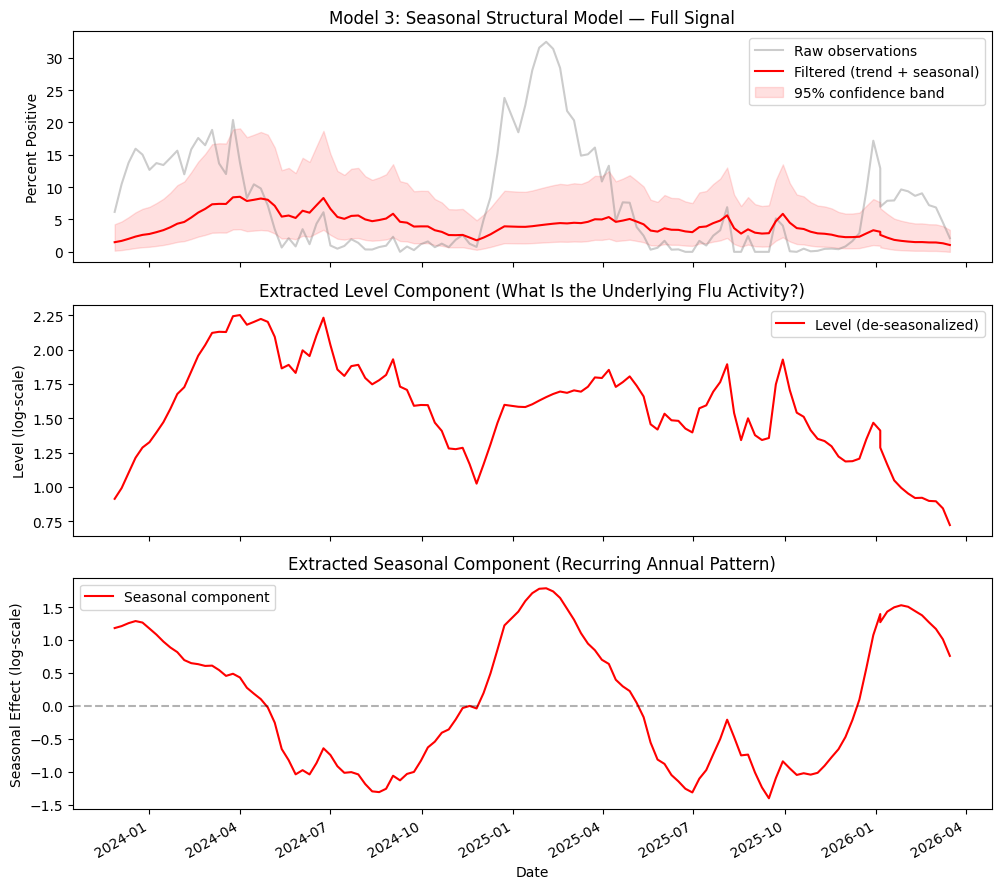

In [94]:
fig, axs = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

skip = 40
test_dates = test['DATE'].values[skip:]

# Panel 1: Full filtered signal (original scale)
axs[0].plot(test_dates, test_raw[skip:], alpha=0.4, label='Raw observations', color='gray')
axs[0].plot(test_dates, seasonal_states[skip:], label='Filtered (trend + seasonal)', color='red')
axs[0].fill_between(test_dates, seasonal_lower[skip:], seasonal_upper[skip:],
                alpha=0.12, color='red', label='95% confidence band')
axs[0].set_ylabel('Percent Positive')
axs[0].set_title('Model 3: Seasonal Structural Model — Full Signal')
axs[0].legend()

# Panel 2: De-seasonalized level (log-scale)
axs[1].plot(test_dates, seasonal_states_log[skip:], color='red', label='Level (de-seasonalized)')
axs[1].set_ylabel('Level (log-scale)')
axs[1].set_title('Extracted Level Component (What Is the Underlying Flu Activity?)')
axs[1].legend()

# Panel 3: Seasonal component (log-scale)
axs[2].plot(test_dates, seasonal_log[skip:], color='red', label='Seasonal component')
axs[2].axhline(0, color='black', linestyle='--', alpha=0.3)
axs[2].set_xlabel('Date')
axs[2].set_ylabel('Seasonal Effect (log-scale)')
axs[2].set_title('Extracted Seasonal Component (Recurring Annual Pattern)')
axs[2].legend()

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### **Compare Models**

In [65]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Compute NLL on test set for each model
nll_test_baseline = neg_log_likelihood_baseline(
    np.log([Q_mle_baseline, R_mle_baseline]), test_log, A_est)
nll_test_llt = neg_log_likelihood_llt(
    np.log([q_level_mle, q_trend_mle, r_mle_llt]), test_log)
nll_test_seasonal = neg_log_likelihood_seasonal(
    np.log([q_level_s, q_trend_s, q_seasonal_s, r_s]), test_log_seasonal, test['WEEK'].values)

# Metrics
models = {'Baseline (Random Walk)': {'filtered': baseline_states,
                                     'n_params': 2,  # Q, R
                                     'nll': nll_test_baseline},
            'Local Linear Trend': {'filtered': llt_states,
                                   'n_params': 3,  # Q_level, Q_trend, R
                                   'nll': nll_test_llt},
            'Seasonal (Fourier)': {'filtered': seasonal_states,
                                   'n_params': 4,  # Q_level, Q_trend, Q_seasonal, R
                                   'nll': nll_test_seasonal}}

comparison_rows = []
skip = 40
for name, m in models.items():
    rmse = np.sqrt(mean_squared_error(test_raw[skip:], m['filtered'][skip:]))
    mae = mean_absolute_error(test_raw[skip:], m['filtered'][skip:])
    aic = 2 * m['n_params'] + 2 * m['nll']
    comparison_rows.append({'Model': name,
                            'RMSE': round(rmse, 4),
                            'MAE': round(mae, 4),
                            'Test NLL': round(m['nll'], 2),
                            'AIC': round(aic, 2),
                            'Num Parameters': m['n_params']})

comparison_df = pd.DataFrame(comparison_rows)
print(comparison_df.to_string(index=False))

                 Model   RMSE    MAE  Test NLL    AIC  Num Parameters
Baseline (Random Walk) 1.4706 0.9180    -16.34 -28.67               2
    Local Linear Trend 1.2975 0.8236    -12.47 -18.95               3
    Seasonal (Fourier) 8.5213 6.1457     -1.96   4.09               4


### **Forecasting**

Forecasts and their associated error variance matrices can be obtained routinely in state space time series analysis based on linear Gaussian models by continuing the Kalman filter beyond $t = n$ with $Z_t= 0$ for $t > n$. Of course, for the computation of $\bar{y}_{n+j}$ and $\bar{F}_{n+1}$ $t > n$, we take $Z_{n+j}$ as their actual values for $j = 1, ..., J$. Similar results hold for forecasting values of the state vector a and hence for forecasting linear functions of elements of at. The results remain valid for MVLUE forecasting in the non-normal case and for Bayesian analysis using Lemmas 2 to 4. These results for forecasting are a particularly elegant feature of state space methods for time series analysis.

For j = 1 the forecast is straightforward:

$$\bar{y}_{n+1} = Z_{n+1}a_{n+1}$$

where $a_{n+1}$ is the estimate (4.21) of $\alpha_{n+1}$ produced by the Kalman filter. 

The conditional mean square error matrix

$$\hat{F}_{n+1} = Z_{n+1}P_{n+1}Z^{'}_{n+1}+H_{n+1}$$

For j = 2, ..., J:

$$\bar{y}_{n+1} = Z_{n+1}\bar{a}_{n+1}$$

with conditional mean square error matrix:
$$\hat{F}_{n+1} = Z_{n+j}\bar{P}_{n+j}Z^{'}_{n+j}+H_{n+j}$$

For j = 1, ..., J-1 and with $\bar{a}_{n+j}=a_{n+1}$:

$$\bar{a}_{n+j+1}=T_{n+j}\bar{a}_{n+j}$$

Also, j = 1, ..., J-1:

$$\bar{P}_{n+j+1}=T_{n+j}\bar{P}_{n+j}T^{'}_{n+j}+R_{n+j}Q_{n+j}R^{'}_{n+j}$$

In [ ]:
def forecast(params, n_steps):
    A, Q, H, xk, Pk = params
    forecasts = []
    uppers = []
    lowers = []
    
    for k in range(n_steps):
        xk, Pk = kf_predict(A, xk, Pk, Q)
        forecast_val = (H @ xk).item()
        sigma = np.sqrt((H @ Pk @ H.T).item())
        forecasts.append(forecast_val)
        uppers.append(forecast_val + 2 * sigma)
        lowers.append(forecast_val - 2 * sigma)
    
    return np.array(forecasts), np.array(uppers), np.array(lowers)

In [67]:
def forecast_seasonal(params, weeks, n_steps):
    A, Q, R, xk, Pk = params
    fourier = build_fourier_features(weeks)
    
    forecasts, uppers, lowers = [], [], []
    
    for k in range(n_steps):
        xk, Pk = kf_predict(A, xk, Pk, Q)
        
        H_k = np.zeros((1, 8))
        H_k[0, 0] = 1
        H_k[0, 2:] = fourier[k]
        
        forecast_val = (H_k @ xk).item()
        sigma = np.sqrt((H_k @ Pk @ H_k.T).item())
        forecasts.append(forecast_val)
        uppers.append(forecast_val + 2 * sigma)
        lowers.append(forecast_val - 2 * sigma)
    
    return np.array(forecasts), np.array(uppers), np.array(lowers)

In [68]:
# Forecast beyond test data
n_forecast = 52  # one year ahead

params_forecast_baseline = A_base, Q_base, H_base, xk_base, Pk_base
forecast_1_log, upper_1_log, lower_1_log = forecast(params_forecast_baseline, n_forecast)

params_forecast_llt = A_llt, Q_llt, H_llt, xk_llt, Pk_llt
forecast_2_log, upper_2_log, lower_2_log = forecast(params_forecast_llt, n_forecast)

# Generate future week numbers continuing from where test ends
last_week = test['WEEK'].values[-1]
forecast_weeks = np.array([(last_week + i) % 52 + 1 for i in range(n_forecast)])
params_forecast_seasonal = A_seasonal, Q_seasonal, R_seasonal, xk_seasonal, Pk_seasonal
forecast_3_log, upper_3_log, lower_3_log = forecast_seasonal(
    params_forecast_seasonal, forecast_weeks, n_forecast)

In [69]:
# Forecast ranges
forecast_start = len(test_raw)
forecast_range = range(forecast_start, forecast_start + n_forecast)
test_range = range(len(test_raw))

In [ ]:
# Generate forecast dates continuing weekly from end of test set
forecast_dates = pd.date_range(start=test['DATE'].values[-1], periods=n_forecast + 1, freq='W')[1:]

def forecast_plots(raw_values, upper, lower, title):
    fig, ax = plt.subplots()
    ax.plot(test['DATE'], test_raw, color='black', marker='.', linestyle='none', alpha=0.5, label='Test observations')
    ax.plot(test['DATE'], baseline_states, color='red', label='Filtered')
    ax.fill_between(test['DATE'], baseline_lower, baseline_upper, alpha=0.12, color='red')
    ax.plot(forecast_dates, raw_values, color='red', linestyle='--', label='Forecast')
    ax.fill_between(forecast_dates, lower, upper, alpha=0.12, color='red')
    ax.axvline(forecast_dates[0], color='black', linestyle='--', alpha=0.3)
    ax.set_xlabel('Date')
    ax.set_ylabel('Percent Positive')
    ax.set_title(title)
    ax.legend()
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

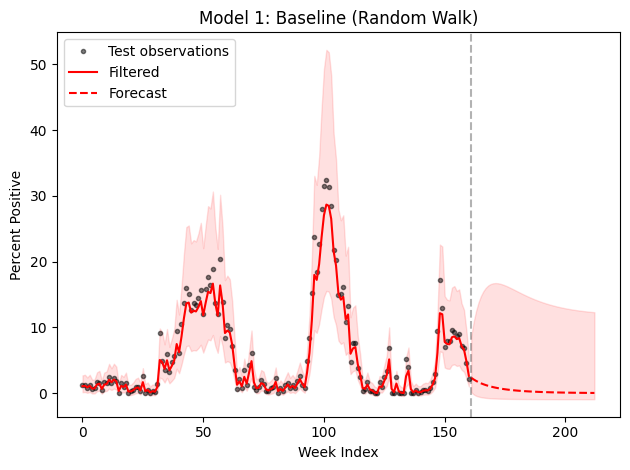

In [71]:
forecast_1_raw = np.expm1(forecast_1_log)
upper_1_raw = np.expm1(upper_1_log)
lower_1_raw = np.expm1(lower_1_log)

forecast_plots(forecast_1_raw, upper_1_raw, lower_1_raw, 'Model 1: Baseline (Random Walk)')

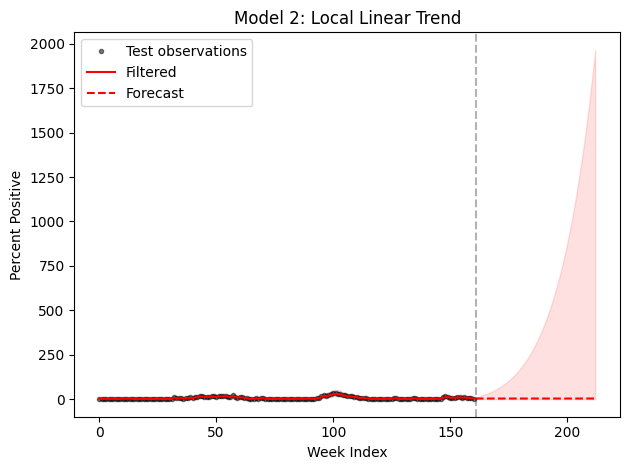

In [72]:
forecast_2_raw = np.expm1(forecast_2_log)
upper_2_raw = np.expm1(upper_2_log)
lower_2_raw = np.expm1(lower_2_log)

forecast_plots(forecast_2_raw, upper_2_raw, lower_2_raw, 'Model 2: Local Linear Trend')

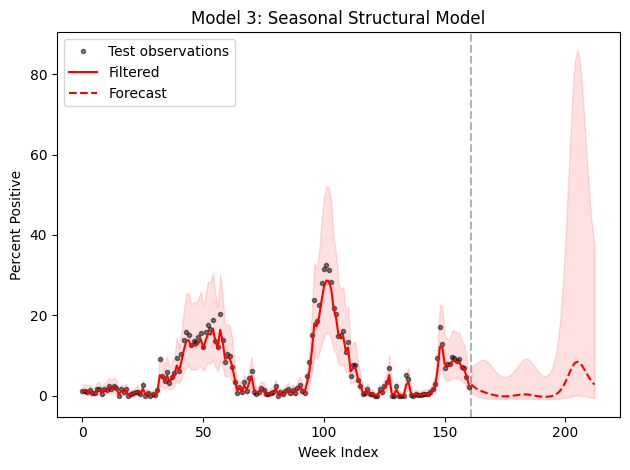

In [73]:
forecast_3_raw = np.expm1(forecast_3_log)
upper_3_raw = np.expm1(upper_3_log)
lower_3_raw = np.expm1(lower_3_log)

forecast_plots(forecast_3_raw, upper_3_raw, lower_3_raw, 'Model 3: Seasonal Structural Model')